This script performs an unweighted displacement rate inversion for each full resolution pixel in the focus areas A-E.
<br><br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [ ]:
#load in all necessary packages
import os,sys
import glob
from osgeo import gdal
from datetime import datetime 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  widget

# Need this function to convert datetime objects to decimal years. Got this off of stackexchange. 
def datetime2year(dt): 
    year_part = dt - datetime(year=dt.year, month=1, day=1)
    year_length = (datetime(year=dt.year + 1, month=1, day=1) - datetime(year=dt.year, month=1, day=1))
    return dt.year + year_part / year_length

In [2]:
# These directory paths need to be updated according to where the user's unwrapped interferograms are situated.
workdir = '/data/ocp4/SuperstitionHills/Data_and_Figs/'  
cropdir = 'cropped_20000_2475_9000_1575/'  
fullResdir = '/data/ocp4/SuperstitionHills/Data_and_Figs/fullRes_unwrapped_interferograms/'     #want to use full resolution unwrapped interferograms
unfiltUnwrappedDir = fullResdir + 'unfilt_unwrapped/'

#load in all dates from all SLCs currently downloaded (only for VV)
dates = [os.path.basename(x) for x in glob.glob(workdir+cropdir+'VV/merged/SLC/'+"/2*")] 
dates = sorted(dates)
num_dates = len(dates)
print(dates)
print(num_dates)
num_igrams = num_dates-1

#convert dates to datetime objects --> then to decimal dates
# convert to datetime objects and plot for the visual timeline
slc_dates=[]
for i in range(0,len(dates)):
    slc_dates.append(datetime.strptime(str(dates[i]).replace('\n',''), '%Y%m%d'))
igram_dates = slc_dates[1::]

# convert to floats
slc_dates_floats = np.ndarray((num_dates,1),dtype='float')
for i in range(num_dates):
    slc_dates_floats[i] = datetime2year(slc_dates[i]) # now an array of floats in years

['20180610', '20180622', '20180704', '20180716', '20180728', '20180809', '20180821', '20180902', '20180914', '20180926', '20181008', '20181020', '20181101', '20181113', '20181125', '20181207', '20181219', '20181231', '20190112', '20190124', '20190205', '20190217', '20190301', '20190313', '20190325', '20190406', '20190430', '20190512', '20190524', '20190605', '20190617', '20190629', '20190711', '20190723', '20190804', '20190816', '20190822', '20190828', '20190903', '20190909', '20190915', '20190921', '20190927', '20191003', '20191009', '20191015', '20191021', '20191027', '20191102', '20191108', '20191114', '20191120', '20191126', '20191202', '20191208', '20191214', '20191220', '20191226', '20200101', '20200107', '20200113', '20200119', '20200125', '20200131', '20200206', '20200212', '20200218', '20200224', '20200301', '20200307', '20200313', '20200319', '20200325', '20200331', '20200406', '20200412', '20200418', '20200430', '20200506', '20200512', '20200518', '20200524', '20200530', '20

In [3]:
#define dimensions of each SLC
x1 = 0; y1= 0    #values are 0 if interferogram has already been cropped
dx= 9000; dy=1575  #actual dimensions

In [4]:
# Coordinates of focus areas
# these are set up: [x_right, y_top, x_left, y_top]
imperial_road = [6820, 100, 7520, 450]
transect_roads = [4500, 650, 6600, 1000] 
ElCentro_airport = [4575, 980, 5275,1265] 
pools = [7700,300, 8400, 650]      
imperial_airport = [6600,800,7300,1075] 

In [ ]:
# Create a mask where values are zero except pixels that are in a focus area. Each focus area has its own number key value.
box_mask = np.zeros((dy,dx),dtype=float)

for y in range(dy):
    for x in range(dx):
        if x>=imperial_road[0] and x<=imperial_road[2] and y<=imperial_road[3] and y>=imperial_road[1]:
            box_mask[y,x] = 1
        if x>=transect_roads[0] and x<=transect_roads[2] and y<=transect_roads[3] and y>=transect_roads[1]:
            box_mask[y,x] = 2
        if x>=ElCentro_airport[0] and x<=ElCentro_airport[2] and y<=ElCentro_airport[3] and y>=ElCentro_airport[1]:
            box_mask[y,x] = 4
        if x>=pools[0] and x<=pools[2] and y<=pools[3] and y>=pools[1]:
            box_mask[y,x] = 5
        if x>=imperial_airport[0] and x<=imperial_airport[2] and y<=imperial_airport[3] and y>=imperial_airport[1]:
            box_mask[y,x] = 6

#need to flip box_mask left-right for plotting
box_mask = np.fliplr(box_mask)

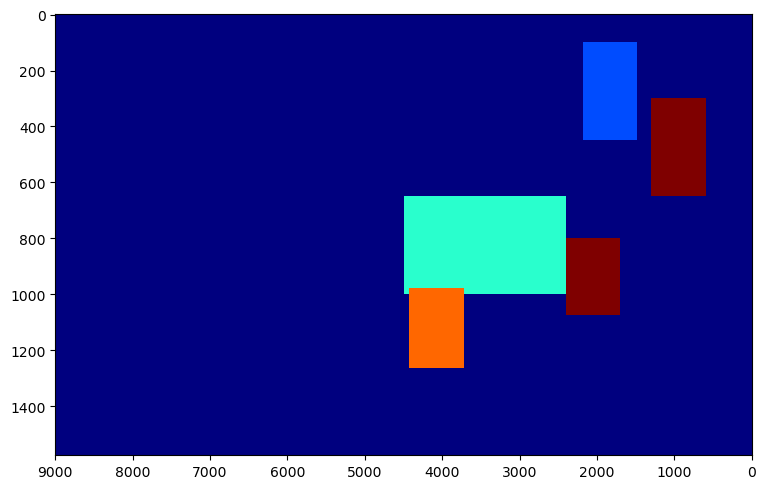

In [6]:
aspect_rat = (21.8/dy) / (34.44/dx)

# plot it to make sure the focus areas look correct/are in the right place.
plt.figure(figsize=(9,5),tight_layout=True)
plt.imshow(box_mask,cmap='jet',aspect=aspect_rat,vmin=0,vmax=5,interpolation='None')
plt.xlim(dx,0)
plt.show()

Select a reference pixel and load the reference phase values at the pixel.

In [13]:
# We selected a reference pixel that has high coherence magnitudes with both methods and is far from any sources of deformation.
saveDir_avg = '../2_Calculating_coherence_2_ways/'
fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray(); f1 = None
fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray(); f2 = None

yR = int(1559)  
xR = int(9000 - 130) 
print(coh_avg_m1[yR,xR])
print(coh_avg_m2[yR,xR])

0.91825604
0.8691138


In [14]:
# Load the reference phase values for each interferogram at the reference pixel selected above.
intDir = unfiltUnwrappedDir
refValue = np.ndarray((num_dates-1,),dtype='float')

for i in range(num_igrams): #for whole time period    #something about this not working
    date1 = dates[i]
    date2 = dates[i+1]
    int_premade = gdal.Open(intDir+date1+"_"+date2+'_'+"unfilt.unw", gdal.GA_ReadOnly)
    int_temp = int_premade.GetRasterBand(1).ReadAsArray(xR,yR,1,1)
    refValue[i] = int_temp[0,0]
    # print(i, refValue[i])

Invert for the rate of each pixel in the ROI

In [ ]:
phs_vals = np.ndarray((num_igrams,),dtype='float')
t = slc_dates_floats[1::].reshape((num_igrams,))

rates = np.ndarray((dy,dx), dtype='float')*np.nan #this is using downlooked dimensions

for y in range(dy):
    for x in range(dx):
        if box_mask[y,x] > 0:
            #print('y: '+str(y)+'  x: '+str(x))  
            for i in range(num_igrams): # for whole time period
                date1 = dates[i]
                date2 = dates[i+1]
                ds = gdal.Open(intDir+date1+"_"+date2+'_'+"unfilt.unw", gdal.GA_ReadOnly)
                phs = ds.GetRasterBand(1).ReadAsArray(x,y,1,1)
                phs_vals[i] = phs[0,0]
            disps = phs_vals - refValue
            cum_disps = np.cumsum(disps) 

            # print(np.shape(cum_disps))
            rates[y,x] = np.polyfit(t,cum_disps,deg=1)[0]   #insert into inversion weighting by coherence

    # print an update every 100 rows
    if(y!=0 and np.remainder(y,10)==0):
        print('Row '+str(y)+' weighted inversions done.')

In [ ]:
# plot it to make sure it worked.
plt.figure(figsize=(9,5),tight_layout=True)
plt.imshow(rates,cmap='seismic',aspect=aspect_rat,vmin=-20,vmax=20,interpolation='None')
plt.xlim(dx,0)
plt.plot(xR,yR,'ko',label='Reference point')
plt.colorbar()
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Now save the rate map.
driver=gdal.GetDriverByName('ISCE')
file_name = 'unweighted_rate_map.r4'
colds = driver.Create(file_name,dx,dy,1,gdal.GDT_Float32)
colds.GetRasterBand(1).WriteArray(rates) # this is in rad/yr
colds=None
print('Rates for time series inverted and saved.')